In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

from google.colab import files

uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()




Saving S&P500_Financials.xlsx to S&P500_Financials.xlsx


,symbol,quarter,revenue(in millions),grossProfit(in millions),operatingIncome(in millions),netIncome(in millions),eps,ebitda(in millions),totalAssets(in millions),totalLiabilities(in millions),...,totalStockholdersEquity(in millions),netCashProvidedByOperatingActivities(in millions),netCashUsedForInvestingActivites(in millions),netCashUsedProvidedByFinancingActivities(in millions),freeCashFlow(in millions),GDP_Growth,Inflation,Interest_Rate,Unemployment_Rate,SP500_Growth
0,AAPL,2004-03-27,19.09,5.30,0.52,0.46,0.0022,0.98,67.35,22.45,...,44.90,0.61,-4.03,-2.24,0.26,NaN,NaN,NaN,NaN,NaN
1,AAPL,2004-06-26,20.14,5.59,0.72,0.61,0.0029,1.21,72.23,24.11,...,48.12,2.11,-4.60,2.11,1.73,NaN,NaN,NaN,NaN,NaN
2,AAPL,2004-09-25,23.50,6.34,1.28,1.06,0.0049,1.87,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
3,AAPL,2004-09-30,0.00,0.00,0.00,0.00,NaN,0.00,80.50,29.74,...,50.76,4.43,-7.02,1.08,3.84,0.948594,0.637733,4.303333,5.433333,NaN
4,AAPL,2004-12-25,34.90,9.96,4.03,2.95,0.0134,4.44,93.62,35.72,...,57.90,7.75,-15.23,2.54,7.17,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1) Check symbol column
if "symbol" not in df.columns:
    raise ValueError("Expected a 'symbol' column in the dataset.")

# Optional cleanup (helps if there are stray spaces / lowercase)
df["symbol"] = df["symbol"].astype(str).str.strip().str.upper()

# 2) Sector mapping (covers all symbols in your Excel)
sector_map = {
    # Information Technology
    "AAPL": "Information Technology",   # Apple
    "MSFT": "Information Technology",   # Microsoft
    "NVDA": "Information Technology",   # NVIDIA
    "AVGO": "Information Technology",   # Broadcom
    "ORCL": "Information Technology",   # Oracle
    "PLTR": "Information Technology",   # Palantir

    # Communication Services
    "GOOGL": "Communication Services",  # Alphabet (Class A)
    "META":  "Communication Services",  # Meta Platforms
    "NFLX":  "Communication Services",  # Netflix

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary",   # Amazon
    "TSLA": "Consumer Discretionary",   # Tesla

    # Financials
    "JPM":  "Financials",               # JPMorgan Chase
    "V":    "Financials",               # Visa
    "MA":   "Financials",               # Mastercard
    "BRK-B":"Financials",               # Berkshire Hathaway (your file uses BRK-B)


    # Health Care
    "JNJ":  "Health Care",              # Johnson & Johnson
    "LLY":  "Health Care",              # Eli Lilly

    # Consumer Staples
    "WMT":  "Consumer Staples",         # Walmart

    # Energy
    "XOM": "Energy",                    # Exxon Mobil
}

# 3) Create Sector column
df["Sector"] = df["symbol"].map(sector_map).fillna("Other")

# 4) Quick validation (so you can see if anything didn't map)
unmapped = sorted(df.loc[df["Sector"].eq("Other"), "symbol"].unique())
print("Unmapped symbols:", unmapped)

print(df[["symbol", "Sector"]].drop_duplicates().sort_values("symbol"))
print("Unique sectors:", sorted(df["Sector"].unique()))


Unmapped symbols: ['NAN']
     symbol                  Sector
0      AAPL  Information Technology
100    AMZN  Consumer Discretionary
184    AVGO  Information Technology
250   BRK-B              Financials
418   GOOGL  Communication Services
502     JNJ             Health Care
586     JPM              Financials
670     LLY             Health Care
754      MA              Financials
838    META  Communication Services
894    MSFT  Information Technology
334     NAN                   Other
978    NFLX  Communication Services
1062   NVDA  Information Technology
1146   ORCL  Information Technology
1230   PLTR  Information Technology
1254   TSLA  Consumer Discretionary
1322      V              Financials
1397    WMT        Consumer Staples
1481    XOM                  Energy
Unique sectors: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Information Technology', 'Other']


In [ ]:
sector_summary = (
    df
    .groupby('Sector')['freeCashFlow(in millions)']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max',
        'skew'

    ])
    .rename(columns={
        'count': 'Observations',
        'mean': 'Mean_FCF',
        'median': 'Median_FCF',
        'std': 'FCF_Volatility/Std.Dev',
        'min': 'Min_FCF',
        'max': 'Max_FCF',
        'skew': 'FCF_Skewness'
    })
)



display(sector_summary)



,Observations,Mean_FCF,Median_FCF,FCF_Volatility/Std.Dev,Min_FCF,Max_FCF,FCF_Skewness
Sector,,,,,,,
Communication Services,224,34.496450,11.169765,51.402052,-15.69712,248.37,1.878619
Consumer Discretionary,152,9.821436,0.745000,46.508519,-177.41000,278.77,1.742713
Consumer Staples,84,31.497381,31.230000,38.378499,-72.97000,107.80,0.067289
Energy,84,56.332500,52.770000,45.581317,-43.28000,195.49,0.487462
Financials,327,29.515740,19.070000,230.929581,-1541.58000,1477.58,-0.489045
Health Care,168,22.858464,17.950000,18.767771,-19.63000,76.46,0.587992
Information Technology,442,48.197366,22.830000,69.248240,-46.07000,441.63,2.223634
Other,0,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 640x480 with 0 Axes>

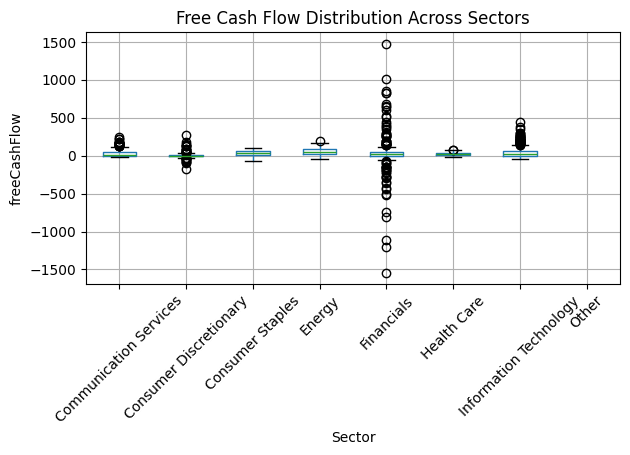

In [ ]:
plt.figure()
df.boxplot(column='freeCashFlow(in millions)', by='Sector', rot=45)
plt.title("Free Cash Flow Distribution Across Sectors")
plt.suptitle("")
plt.xlabel("Sector")
plt.ylabel("freeCashFlow")
plt.tight_layout()
plt.show()

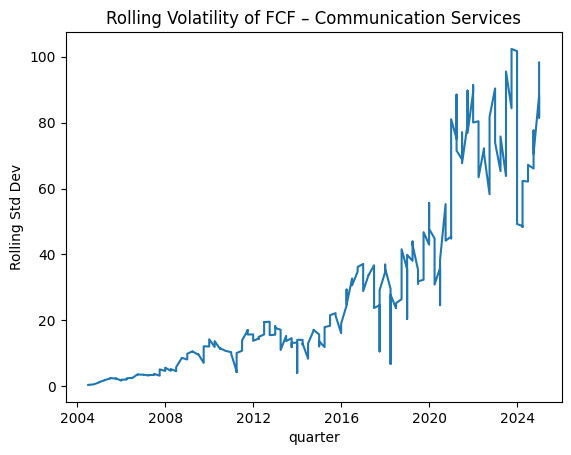

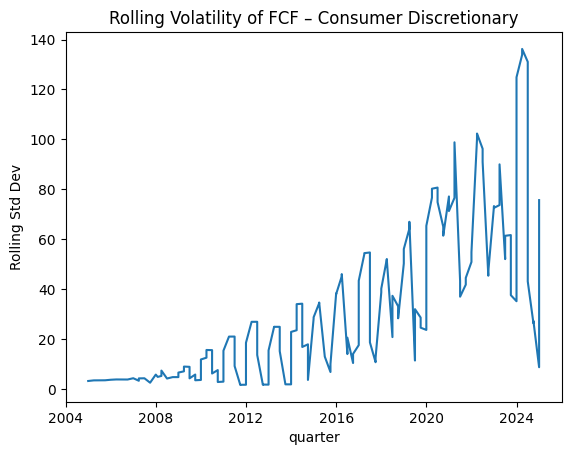

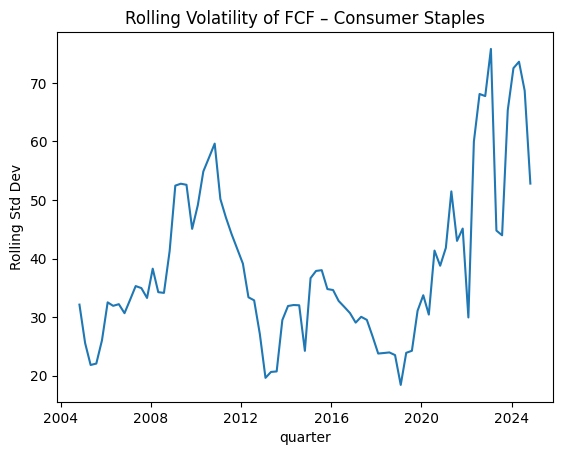

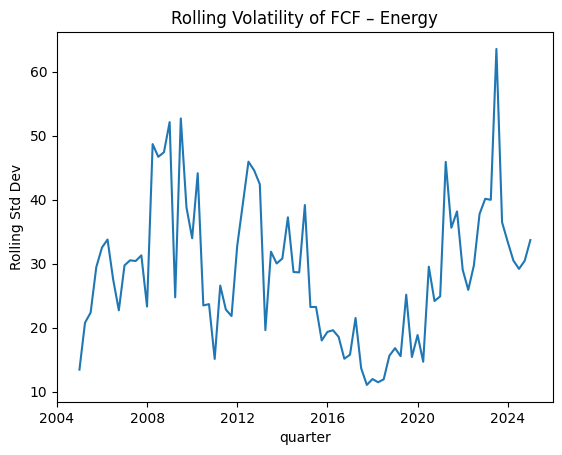

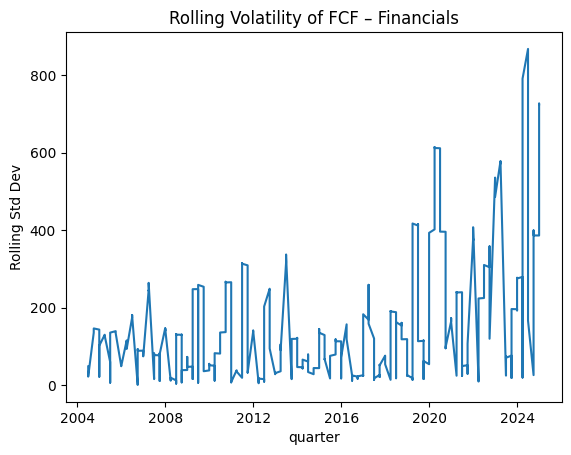

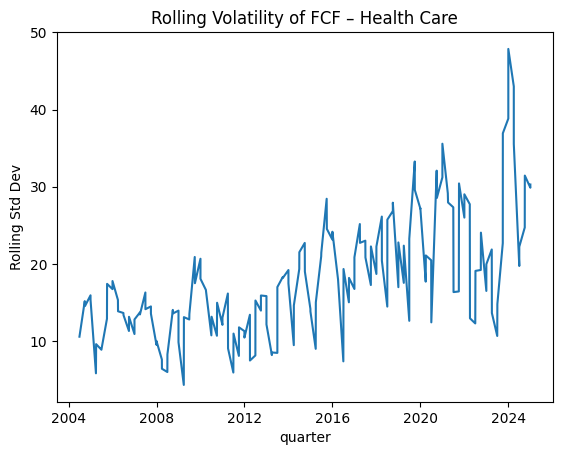

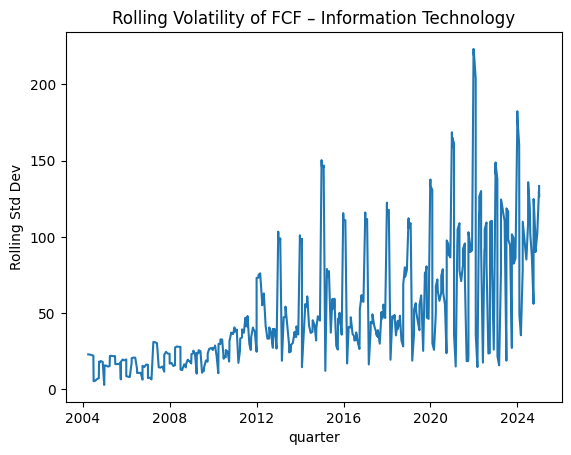

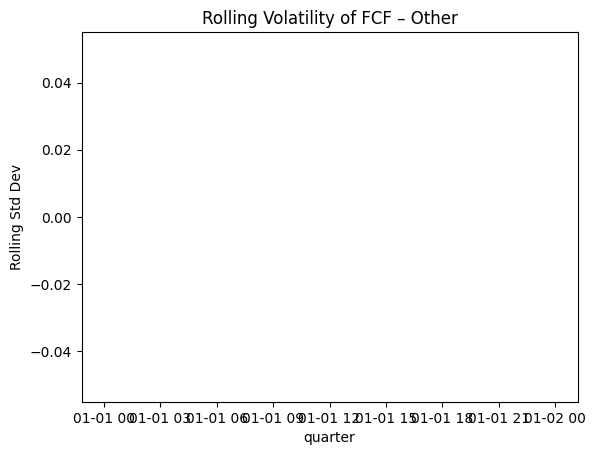

In [ ]:
df['quarter'] = pd.to_datetime(df['quarter'])

rolling_vol = (
    df
    .set_index('quarter')
    .sort_index()
    .groupby('Sector')
    ['freeCashFlow(in millions)']
    .rolling(window=4)
    .std()
    .reset_index()
)

for sector in rolling_vol['Sector'].unique():
    temp = rolling_vol[rolling_vol['Sector'] == sector]
    plt.figure()
    plt.plot(temp['quarter'], temp['freeCashFlow(in millions)'])
    plt.title(f"Rolling Volatility of FCF – {sector}")
    plt.xlabel("quarter")
    plt.ylabel("Rolling Std Dev")
    plt.show()

In [ ]:
forecast_difficulty = sector_summary.copy()

forecast_difficulty['High_Volatility'] = (
    forecast_difficulty['FCF_Volatility/Std.Dev'] >
    forecast_difficulty['FCF_Volatility/Std.Dev'].median()
)

forecast_difficulty['High_Skewness'] = (
    abs(forecast_difficulty['FCF_Skewness']) > 1
)

forecast_difficulty['Forecasting_Difficulty'] = np.where(
    forecast_difficulty['High_Volatility'] & forecast_difficulty['High_Skewness'],
    'High',
    'Moderate'
)

print(forecast_difficulty)
# Save output
forecast_difficulty.to_excel("forecast_difficulty.xlsx", index=False)
files.download("forecast_difficulty.xlsx")

forecast_difficulty.head()

                        Observations   Mean_FCF  Median_FCF  \
Sector                                                        
Communication Services           224  34.496450   11.169765   
Consumer Discretionary           152   9.821436    0.745000   
Consumer Staples                  84  31.497381   31.230000   
Energy                            84  56.332500   52.770000   
Financials                       327  29.515740   19.070000   
Health Care                      168  22.858464   17.950000   
Information Technology           442  48.197366   22.830000   
Other                              0        NaN         NaN   

                        FCF_Volatility/Std.Dev     Min_FCF  Max_FCF  \
Sector                                                                
Communication Services               51.402052   -15.69712   248.37   
Consumer Discretionary               46.508519  -177.41000   278.77   
Consumer Staples                     38.378499   -72.97000   107.80   
Energy        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Observations,Mean_FCF,Median_FCF,FCF_Volatility/Std.Dev,Min_FCF,Max_FCF,FCF_Skewness,High_Volatility,High_Skewness,Forecasting_Difficulty
Sector,,,,,,,,,,
Communication Services,224,34.496450,11.169765,51.402052,-15.69712,248.37,1.878619,True,True,High
Consumer Discretionary,152,9.821436,0.745000,46.508519,-177.41000,278.77,1.742713,False,True,Moderate
Consumer Staples,84,31.497381,31.230000,38.378499,-72.97000,107.80,0.067289,False,False,Moderate
Energy,84,56.332500,52.770000,45.581317,-43.28000,195.49,0.487462,False,False,Moderate
Financials,327,29.515740,19.070000,230.929581,-1541.58000,1477.58,-0.489045,True,False,Moderate


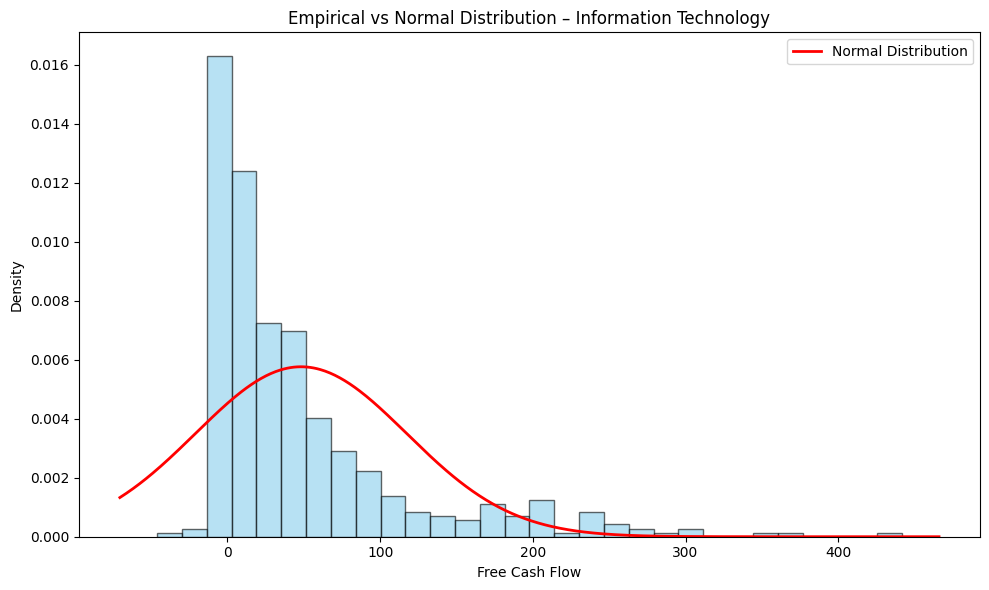

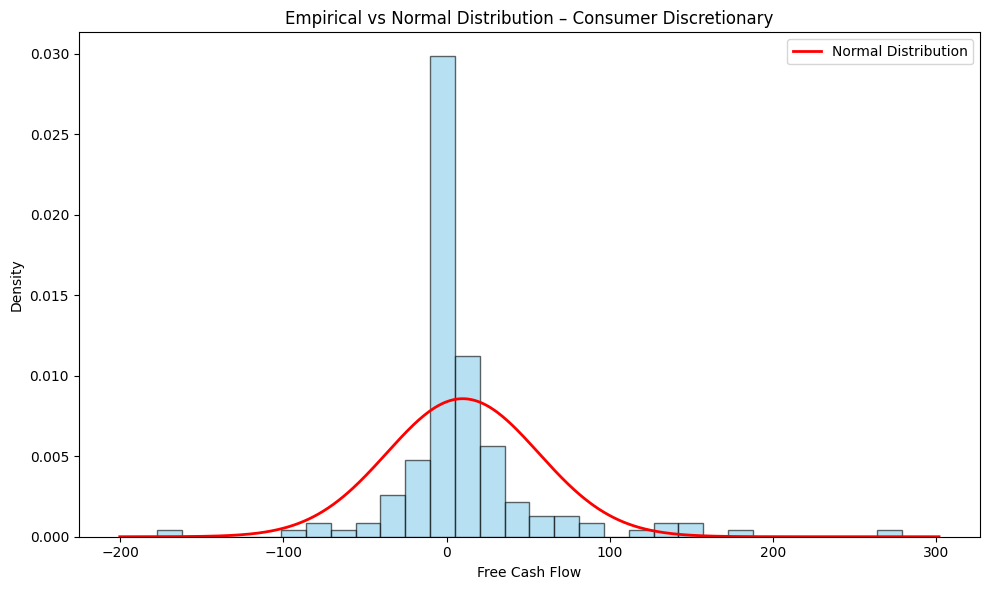

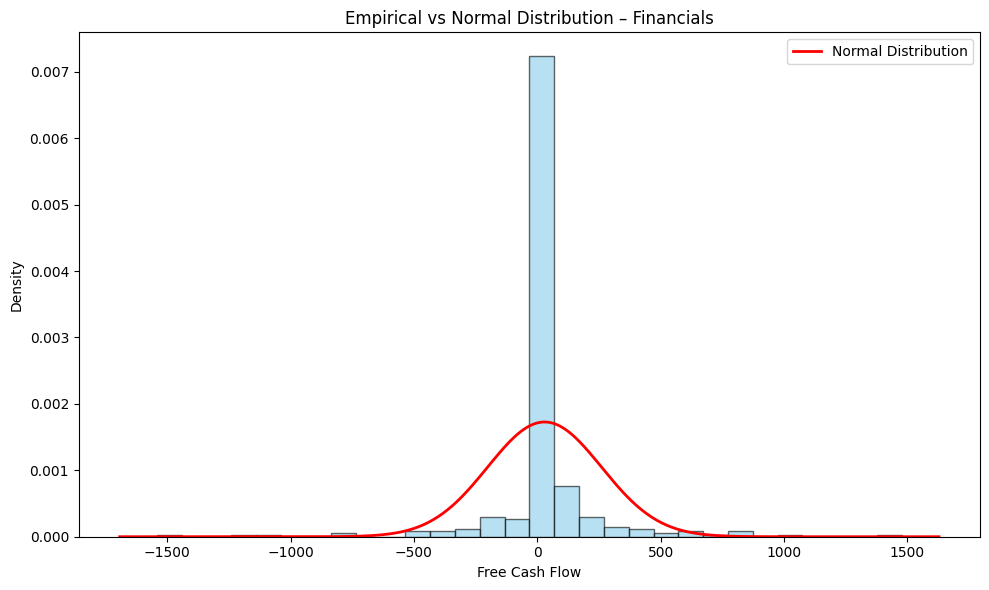

No data available for Other to plot.


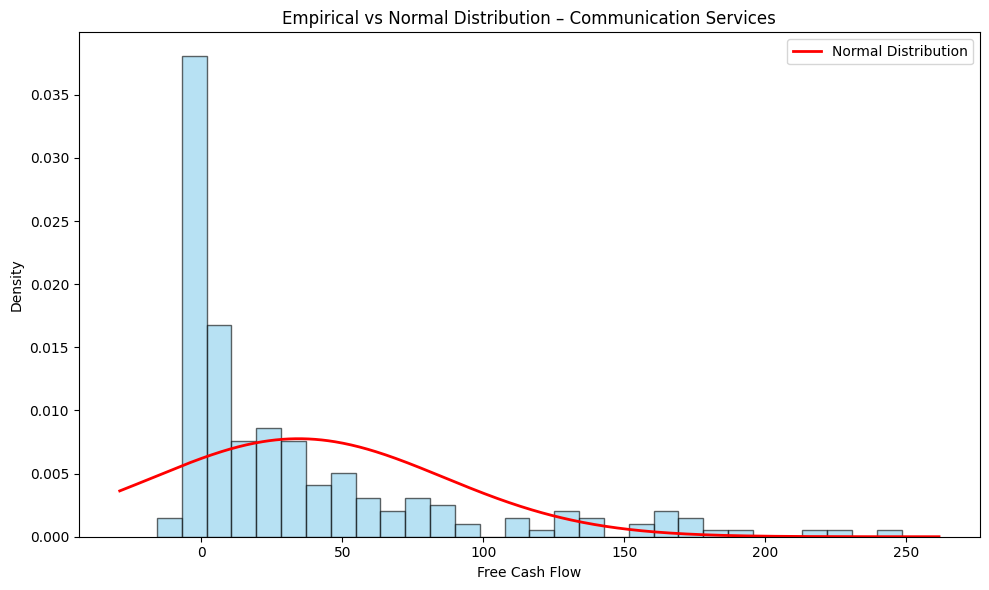

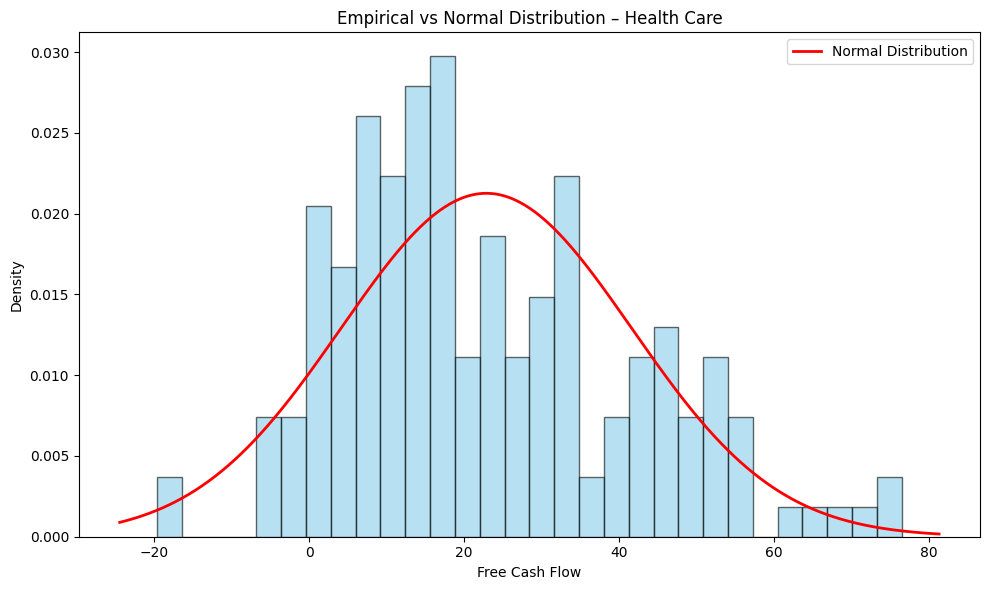

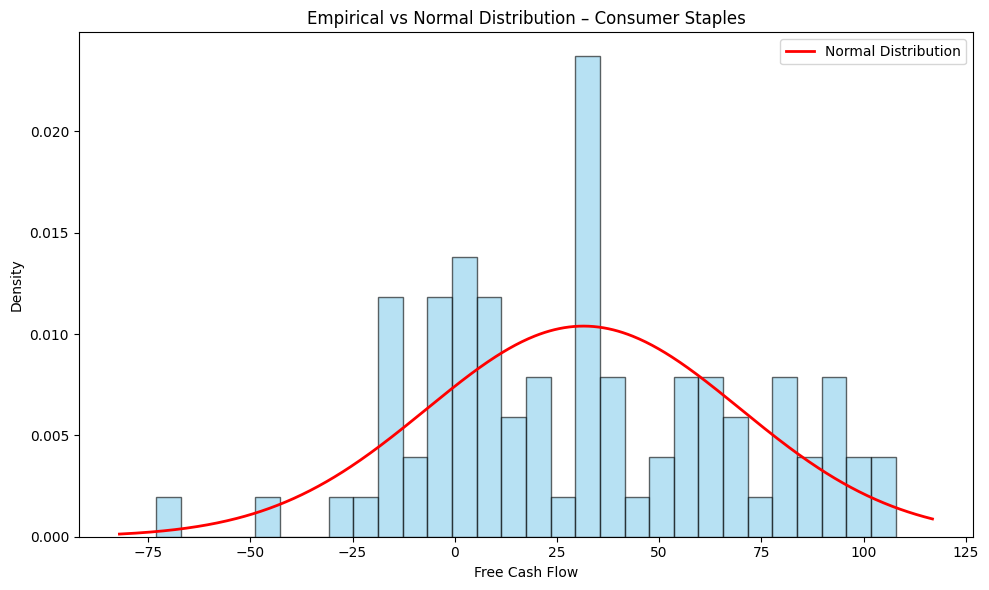

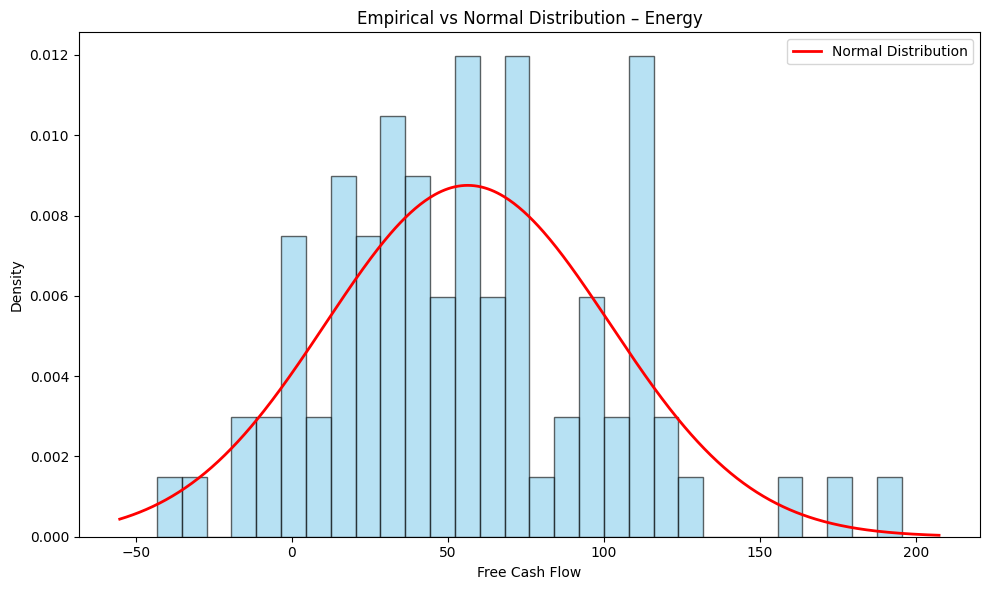

In [ ]:
from scipy.stats import norm
import matplotlib.pyplot as plt

for sector_name in df['Sector'].unique():
    data = df[df['Sector'] == sector_name]['freeCashFlow(in millions)'].dropna()

    if not data.empty:
        mean, std = data.mean(), data.std()

        plt.figure(figsize=(10, 6))
        plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

        # Normal bell curve
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 500)
        plt.plot(x, norm.pdf(x, mean, std), 'r-', lw=2, label='Normal Distribution')

        plt.title(f"Empirical vs Normal Distribution – {sector_name}")
        plt.xlabel("Free Cash Flow")
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data available for {sector_name} to plot.")

In [ ]:
df["freeCashFlow(in billions)"].describe()


KeyError: 'freeCashFlow(in billions)'

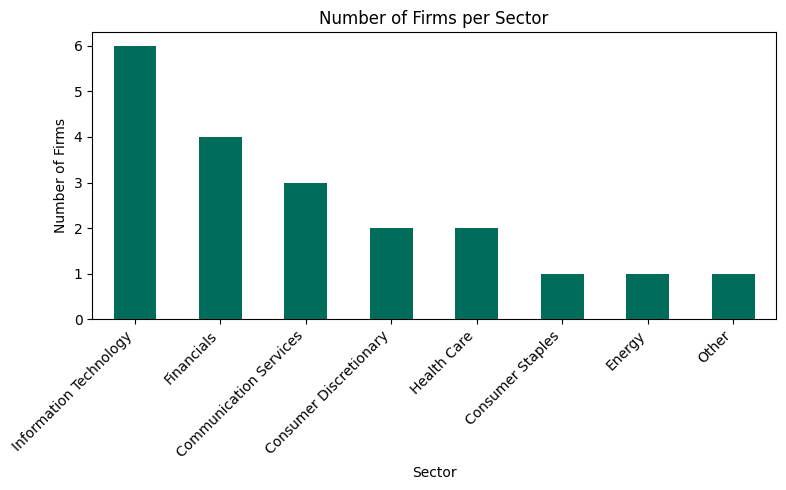

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("S&P500_Financials.xlsx")

# Safety check
if "symbol" not in df.columns:
    raise ValueError("Expected a 'symbol' column in the dataset.")

# Clean symbols
df["symbol"] = df["symbol"].astype(str).str.strip().str.upper()

# Sector mapping
sector_map = {
    "AAPL": "Information Technology",
    "MSFT": "Information Technology",
    "NVDA": "Information Technology",
    "AVGO": "Information Technology",
    "ORCL": "Information Technology",
    "PLTR": "Information Technology",
    "GOOGL": "Communication Services",
    "META": "Communication Services",
    "NFLX": "Communication Services",
    "AMZN": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",
    "JPM": "Financials",
    "V": "Financials",
    "MA": "Financials",
    "BRK-B": "Financials",
    "JNJ": "Health Care",
    "LLY": "Health Care",
    "WMT": "Consumer Staples",
    "XOM": "Energy",
}

# Assign sectors
df["Sector"] = df["symbol"].map(sector_map).fillna("Other")

# Count firms per sector
sector_counts = (
    df[["symbol", "Sector"]]
    .drop_duplicates()
    .value_counts("Sector")
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
sector_counts.plot(kind="bar", color="#006D5B")
plt.title("Number of Firms per Sector")
plt.xlabel("Sector")
plt.ylabel("Number of Firms")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create metric dictionaries
sectors = [
    "Communication Services",
    "Consumer Discretionary",
    "Energy",
    "Financials",
    "Health Care",
    "Information Technology",
    "Other"
]

# ---- MAE ----
mae = pd.DataFrame({
    "Linear Regression": [24.88, 28.61, 11.51, 16.42, 10.93, 23.16, 2.96],
    "LSTM": [23.93, 27.51, 17.08, 73.99, 10.36, 28.84, 7.85],
    "QSVM": [40.18, 57.01, 25.15, 229.16, 19.67, 46.82, 20.34],
    "QNN": [80.59, 62.99, 29.12, 331.50, 19.78, 70.75, 38.54]
}, index=sectors)

# ---- RMSE ----
rmse = pd.DataFrame({
    "Linear Regression": [29.61, 33.25, 16.70, 19.61, 16.20, 28.60, 3.70],
    "LSTM": [22.84, 22.16, 18.86, 77.81, 12.40, 47.99, 9.74],
    "QSVM": [59.69, 54.66, 26.14, 295.04, 19.64, 59.72, 22.72],
    "QNN": [91.10, 89.96, 38.15, 568.43, 27.80, 69.52, 41.06]
}, index=sectors)

# ---- R² ----
r2 = pd.DataFrame({
    "Linear Regression": [0.856, 0.841, 0.674, 0.999, 0.659, 0.725, 0.992],
    "LSTM": [0.806, 0.764, 0.528, 0.944, 0.755, 0.488, 0.893],
    "QSVM": [0.524, 0.016, -0.246, 0.344, 0.374, 0.126, 0.471],
    "QNN": [-0.405, -0.348, -0.869, 0.020, 0.313, -0.896, -0.104]
}, index=sectors)


In [ ]:
def plot_heatmap(df, title, cbar_label, cmap):
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(df.values, aspect="auto", cmap=cmap)

    ax.set_xticks(np.arange(len(df.columns)))
    ax.set_yticks(np.arange(len(df.index)))
    ax.set_xticklabels(df.columns, rotation=30, ha="right")
    ax.set_yticklabels(df.index)

    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            ax.text(j, i, f"{df.iloc[i, j]:.2f}",
                    ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()


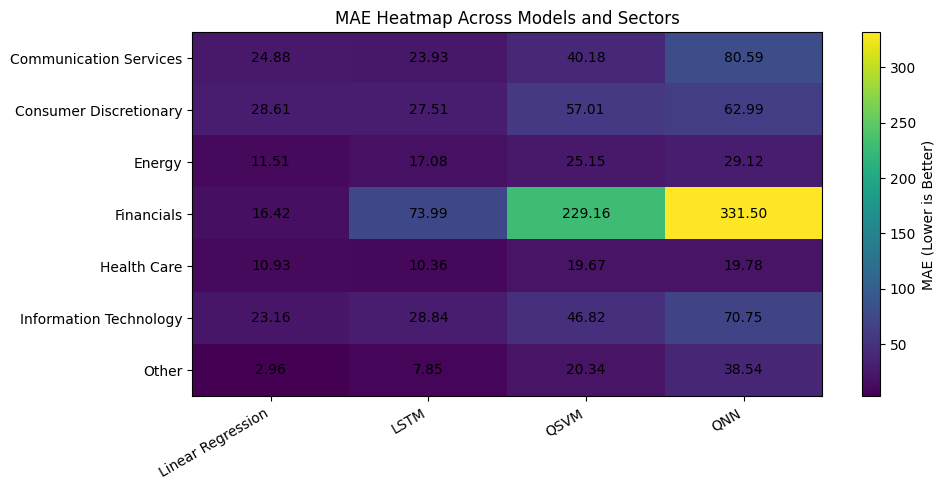

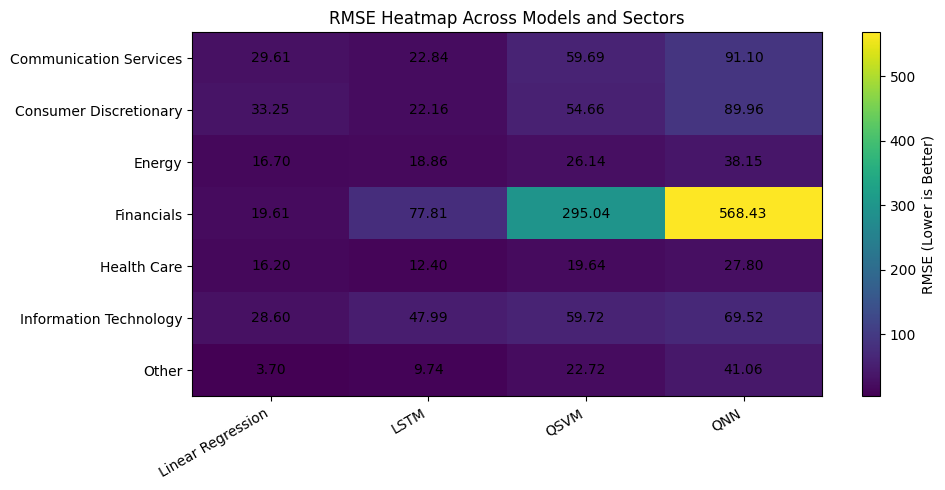

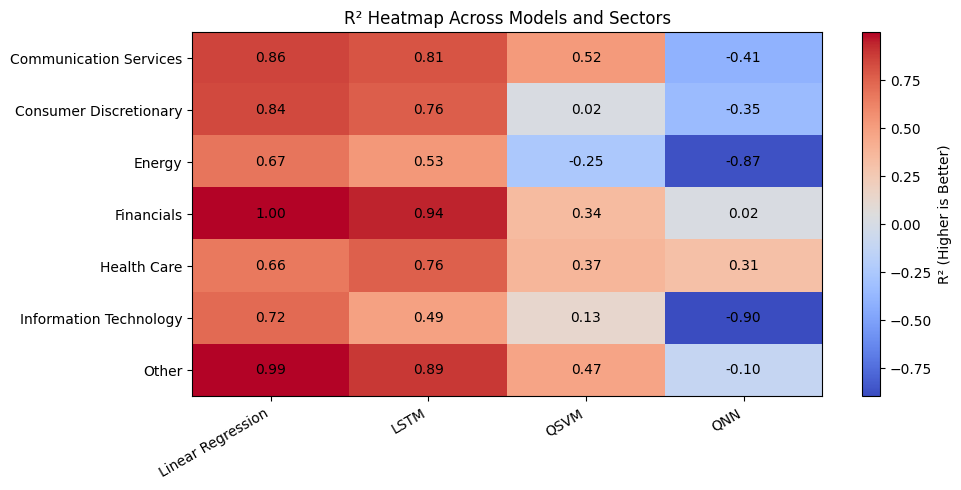

In [ ]:
plot_heatmap(
    mae,
    "MAE Heatmap Across Models and Sectors",
    "MAE (Lower is Better)",
    cmap="viridis"
)

plot_heatmap(
    rmse,
    "RMSE Heatmap Across Models and Sectors",
    "RMSE (Lower is Better)",
    cmap="viridis"
)

plot_heatmap(
    r2,
    "R² Heatmap Across Models and Sectors",
    "R² (Higher is Better)",
    cmap="coolwarm"
)
